# Modeling for the new features

In [2]:
import pathlib
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW, PROC = ROOT / cfg['paths']['raw'], ROOT / cfg['paths']['processed']
H = cfg['labels']['horizon']            # forward-return horizon in trading days
MIN_GROUP = cfg['labels']['min_group']  # min peers a category needs that day to get a label

In [11]:
# Load Dataset 
d = pd.read_parquet(PROC / "features_v3.parquet")
print(d.columns.tolist())
print(d.shape)
print(d.index)



['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ema20_dist', 'ema50_dist', 'macd', 'macd_signal', 'macd_hist', 'adx_14', 'rsi_14', 'willr_14', 'bb_pctb', 'stoch_k', 'stoch_d', 'vol_20d', 'vol_zscore', 'bb_bandwidth', 'atr_14', 'beta_60d', 'obv', 'mfi_14', 'cmf_20', 'dollar_vol_20d', 'rel_volume_20d', 'cs_rank_ret_5d', 'cs_rank_ret_20d', 'cs_rank_rsi', 'cs_rank_volatility', 'cs_rank_volume', 'peer_rank_20d', 'd_rsi_5d', 'd_peer_rank_5d', 'd_vol_5d', 'd_macd_hist_5d', 'd_volume_pct_5d', 'cat_ret_5d', 'cat_disp_5d', 'beat_rate_20d', 'mkt_ret_1d', 'mkt_vol_20d', 'mkt_vol_zscore', 'breadth_50d']
(3969606, 44)
MultiIndex([('2016-07-11',  'AAA'),
            ('2016-07-11', 'AADR'),
            ('2016-07-11', 'AAXJ'),
            ('2016-07-11', 'ABEQ'),
            ('2016-07-11', 'ACES'),
            ('2016-07-11', 'ACVF'),
            ('2016-07-11', 'ACWF'),
            ('2016-07-11', 'ACWI'),
            ('2016-07-11', 'ACWX'),
            ('2016-07-11', 'ADIV'),
            ...
     

In [3]:
prices = pd.read_parquet(RAW / "prices.parquet")
metadata = pd.read_parquet(RAW / "metadata.parquet")


## Labelling

In [ ]:
# ============================================================
# LABELS + attach to d  ->  dataset
# ============================================================
HORIZON, SKIP, THRESHOLD, MIN_GROUP = 20, 5, 0.005, 3

# --- labelable universe: categories with >= MIN_GROUP real peers ---
lcat = metadata["category"].reindex(prices.columns)
counts = lcat.value_counts()
keep_cats = counts[(counts >= MIN_GROUP) & (counts.index != "Uncategorized")].index
cols = lcat[lcat.isin(keep_cats)].index
px, lcat = prices[cols], lcat[cols]
print(f"funds kept for labeling: {len(cols)} | categories: {lcat.nunique()}")

# --- forward return: skip next 5 days, hold 20 (also acts as the model embargo) ---
fwd = px.shift(-(HORIZON + SKIP)) / px.shift(-SKIP) - 1.0

# --- leave-one-out category peer mean ---
grp_sum = fwd.T.groupby(lcat).transform("sum").T
grp_n   = fwd.notna().T.groupby(lcat).transform("sum").T
peer_mean = (grp_sum - fwd.fillna(0)) / (grp_n - fwd.notna().astype(int)).replace(0, np.nan)

# --- relative perf -> 3-class label ---
rel = fwd - peer_mean
label = pd.DataFrame(
    np.where(rel > THRESHOLD, "Outperform",
             np.where(rel < -THRESHOLD, "Underperform", "Neutral")),
    index=rel.index, columns=rel.columns,
).where(rel.notna())

# --- stack wide -> long, named (date, ticker) to match d ---
def _stack(df):
    s = df.stack(future_stack=True)
    s.index.names = ["date", "ticker"]
    return s

lbl = pd.concat({"fwd_ret": _stack(fwd), "rel": _stack(rel), "label": _stack(label)}, axis=1)
lbl = lbl.dropna(subset=["label"])
lbl["target"] = lbl["label"].map({"Underperform": 0, "Neutral": 1, "Outperform": 2})

# --- force Timestamp on both date levels (str-vs-Timestamp = the empty-join bug) ---
lbl.index = lbl.index.set_levels(pd.to_datetime(lbl.index.levels[0]), level="date")
d.index = d.index.set_levels(
    pd.to_datetime(d.index.levels[0]), level="date")

# --- attach labels, keep only labeled rows ---
dataset = d.copy()
dataset["target"]  = lbl["target"].reindex(dataset.index)
dataset["fwd_ret"] = lbl["fwd_ret"].reindex(dataset.index)
dataset["rel"]     = lbl["rel"].reindex(dataset.index)
dataset = dataset.dropna(subset=["target"])
dataset["target"] = dataset["target"].astype("int8")

# --- report + save ---
print("labeled rows:", f"{len(dataset):,}", "/", f"{len(d):,}")
print((dataset["target"].value_counts(normalize=True) * 100).round(2))
dataset.to_parquet(PROC / "dataset_v3.parquet")
print("saved -> dataset_v3.parquet", dataset.shape)

In [23]:
# ============================================================
# LABEL BASE — shared by all schemes below
# ============================================================
HORIZON, SKIP, MIN_GROUP = 20, 5, 3

lcat = metadata["category"].reindex(prices.columns)
counts = lcat.value_counts()
keep_cats = counts[(counts >= MIN_GROUP) & (counts.index != "Uncategorized")].index
cols = lcat[lcat.isin(keep_cats)].index
px, lcat = prices[cols], lcat[cols]

# forward return (skip 5, hold 20)
fwd = px.shift(-(HORIZON + SKIP)) / px.shift(-SKIP) - 1.0

# category leave-one-out peer mean -> category-adjusted excess
grp_sum = fwd.T.groupby(lcat).transform("sum").T
grp_n   = fwd.notna().T.groupby(lcat).transform("sum").T
peer_mean = (grp_sum - fwd.fillna(0)) / (grp_n - fwd.notna().astype(int)).replace(0, np.nan)
rel = fwd - peer_mean

# market mean (all funds that day) -> market-adjusted excess
rel_mkt = fwd.sub(fwd.mean(axis=1), axis=0)

# trailing realized vol, horizon-scaled -> info-ratio-style excess (for vol-adjusted labels)
daily_vol = px.pct_change(fill_method=None).rolling(20).std()
rel_ir = rel / (daily_vol * np.sqrt(HORIZON)).replace(0, np.nan)

def _stack(df):
    s = df.stack(future_stack=True); s.index.names = ["date", "ticker"]; return s

fwd_l, rel_l = _stack(fwd), _stack(rel)

def per_day_qcut(wide, q, labels):
    s = _stack(wide).dropna()
    return s.groupby(level="date").transform(
        lambda x: pd.qcut(x.rank(method="first"), q, labels=labels)).astype("int8")

def per_day_extremes(wide, lo, hi):
    s = _stack(wide).dropna()
    r = s.groupby(level="date").rank(pct=True)
    return pd.Series(np.where(r >= hi, 2, np.where(r <= lo, 0, 1)), index=r.index).astype("int8")

def make_labels(target):
    out = pd.concat({"target": target, "fwd_ret": fwd_l, "rel": rel_l}, axis=1).dropna(subset=["target"])
    out["target"] = out["target"].astype("int8")
    return out

In [33]:
labels_long = make_labels(per_day_qcut(rel, 3, [0, 1, 2]))
print((labels_long["target"].value_counts(normalize=True) * 100).round(1))

target
2    33.4
0    33.3
1    33.3
Name: proportion, dtype: float64


In [35]:
d.index = d.index.set_levels(
    pd.to_datetime(d.index.levels[0]), level="date")
dataset = d.copy()
dataset["target"]  = labels_long["target"].reindex(dataset.index)
dataset["fwd_ret"] = labels_long["fwd_ret"].reindex(dataset.index)
dataset["rel"]     = labels_long["rel"].reindex(dataset.index)
dataset = dataset.dropna(subset=["target"])
dataset["target"] = dataset["target"].astype("int8")
print("labeled rows:", f"{len(dataset):,}", "/", f"{len(d):,}")

labeled rows: 3,332,264 / 3,969,606


# Catboost

In [31]:
model = CatBoostClassifier(
    iterations=10000,
    learning_rate=0.045,
    depth=7,
loss_function="MultiClassOneVsAll",
eval_metric="TotalF1:average=Macro",
l2_leaf_reg=5,
    random_strength=1,
    border_count=254,
    bootstrap_type="Bayesian",
    bagging_temperature=1,
    task_type="GPU",
    random_seed=42,
    use_best_model=True,
    verbose=100,
    early_stopping_rounds=500,
)
HORIZON, SKIP = 20, 5
NON_FEATURES = ["target", "fwd_ret", "rel"]
features = yum.columns
target = "target"

# base model — deepcopy'd fresh each window inside the loop
#print(f"{len(features)} features | dataset {dataset.shape}")
features

Index(['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ema20_dist',
       'ema50_dist', 'macd', 'macd_signal', 'macd_hist', 'adx_14', 'rsi_14',
       'willr_14', 'bb_pctb', 'stoch_k', 'stoch_d', 'vol_20d', 'vol_zscore',
       'bb_bandwidth', 'atr_14', 'beta_60d', 'obv', 'mfi_14', 'cmf_20',
       'dollar_vol_20d', 'rel_volume_20d', 'cs_rank_ret_5d', 'cs_rank_ret_20d',
       'cs_rank_rsi', 'cs_rank_volatility', 'cs_rank_volume', 'peer_rank_20d',
       'd_rsi_5d', 'd_peer_rank_5d', 'd_vol_5d', 'd_macd_hist_5d',
       'd_volume_pct_5d', 'cat_ret_5d', 'cat_disp_5d', 'beat_rate_20d',
       'mkt_ret_1d', 'mkt_vol_20d', 'mkt_vol_zscore', 'breadth_50d'],
      dtype='object')

In [32]:
from copy import deepcopy
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

EMBARGO = HORIZON + SKIP
WINDOWS = {"6M": 6, "1Y": 12, "2Y": 24, "3Y": 36, "4Y": 48, "5Y": 60}
TEST_YEAR = 2026
dataset=bang
date_index = dataset.index.get_level_values("date")
test_start = pd.Timestamp(f"{TEST_YEAR}-01-01")
test_end   = pd.Timestamp(f"{TEST_YEAR}-12-31")
cut = test_start - pd.offsets.BDay(EMBARGO)

test_mask = (date_index >= test_start) & (date_index <= test_end)
test_data = dataset.loc[test_mask]
X_test, y_test = test_data[features], test_data[target]

all_results, all_predictions, all_confusions, all_models = [], {}, {}, {}

for window_name, window_months in WINDOWS.items():
    print("\n" + "=" * 80)
    print(f"TRAINING WINDOW: {window_name}")
    print("=" * 80)

    train_start = test_start - pd.DateOffset(months=window_months)
    train_mask = (date_index >= train_start) & (date_index <= cut)
    if train_mask.sum() == 0 or test_mask.sum() == 0:
        print(f"Skipping {window_name}: no data in range")
        continue

    train = dataset.loc[train_mask]

    # validation = last ~10% of the training dates (embargoed)
    train_dates = train.index.get_level_values("date")
    dates = np.sort(train_dates.unique())
    val_start = dates[int(len(dates) * 0.90)]
    val_cut = val_start - pd.offsets.BDay(EMBARGO)
    fit_mask = train_dates <= val_cut
    val_mask = train_dates >= val_start

    X_fit, y_fit = train.loc[fit_mask, features], train.loc[fit_mask, target]
    X_val, y_val = train.loc[val_mask, features], train.loc[val_mask, target]
    if len(X_fit) == 0 or len(X_val) == 0:
        print(f"Skipping {window_name}: empty fit/val split")
        continue

    # recency sample weights: exp decay by age of each fit row
    fit_dates = X_fit.index.get_level_values("date")
    age_years = ((fit_dates.max() - fit_dates).days / 365.25).to_numpy()
    decay_rate = 0.5
    sample_weight = np.exp(-decay_rate * age_years)
    sample_weight = sample_weight / sample_weight.mean()
    print(f"weights: min={sample_weight.min():.3f} max={sample_weight.max():.3f} mean={sample_weight.mean():.3f}")

    model_run = deepcopy(model)
    model_run.fit(X_fit, y_fit, sample_weight=sample_weight, eval_set=(X_val, y_val))

    pred = model_run.predict(X_test).astype(int).ravel()
    macro_f1 = f1_score(y_test, pred, average="macro")
    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred, labels=[0, 1, 2])

    print(f"{window_name}: fit={len(X_fit):,} val={len(X_val):,} test={len(X_test):,} "
          f"| F1={macro_f1:.4f} | Acc={acc:.4f}")

    out = test_data.copy()
    out["prediction"] = pred
    out["window"] = window_name
    all_predictions[window_name] = out
    all_confusions[window_name] = cm
    all_models[window_name] = model_run
    all_results.append({"window": window_name, "train_start": train_start,
                        "fit": len(X_fit), "val": len(X_val), "test": len(X_test),
                        "macro_f1": macro_f1, "accuracy": acc})
    if window_name=="4Y":
        model_x=deepcopy(model_run)

results_df = pd.DataFrame(all_results)
print("\n" + "=" * 80)
print(f"WINDOW COMPARISON — TEST YEAR {TEST_YEAR}")
print("=" * 80)
print(results_df)


TRAINING WINDOW: 6M
weights: min=0.933 max=1.069 mean=1.000
0:	learn: 0.5189071	test: 0.4797050	best: 0.4797050 (0)	total: 19.1ms	remaining: 3m 11s
100:	learn: 0.6004361	test: 0.4637891	best: 0.4824485 (1)	total: 1.58s	remaining: 2m 35s
200:	learn: 0.6303920	test: 0.4607923	best: 0.4824485 (1)	total: 2.93s	remaining: 2m 22s
300:	learn: 0.6520360	test: 0.4572215	best: 0.4824485 (1)	total: 4.22s	remaining: 2m 15s
400:	learn: 0.6688867	test: 0.4511147	best: 0.4824485 (1)	total: 5.62s	remaining: 2m 14s
500:	learn: 0.6830734	test: 0.4520892	best: 0.4824485 (1)	total: 7.02s	remaining: 2m 13s
bestTest = 0.4824484864
bestIteration = 1
Shrink model to first 2 iterations.
6M: fit=92,617 val=14,564 test=139,020 | F1=0.4764 | Acc=0.4798

TRAINING WINDOW: 1Y
weights: min=0.830 max=1.190 mean=1.000
0:	learn: 0.5128688	test: 0.3982164	best: 0.3982164 (0)	total: 18.4ms	remaining: 3m 3s
100:	learn: 0.5775024	test: 0.4176162	best: 0.4273847 (3)	total: 1.66s	remaining: 2m 43s
200:	learn: 0.5993384	test:

In [5]:
imp = pd.DataFrame({
    "feature": d.columns,
    "importance": model_run.get_feature_importance()
}).sort_values("importance", ascending=False)

imp.head(30)

NameError: name 'd' is not defined

In [33]:
# --- portfolio evaluation per window ---

summary_rows = []

for window_name in WINDOWS.keys():

    if window_name not in all_predictions:
        continue

    print("\n" + "=" * 80)
    print(f"RESULTS: {window_name}")
    print("=" * 80)

    preds = all_predictions[window_name]

    print("\n=== confusion matrix ===")
    cm_df = pd.DataFrame(
        all_confusions[window_name],
        index=["True_0", "True_1", "True_2"],
        columns=["Pred_0", "Pred_1", "Pred_2"]
    )
    print(cm_df)

    print("\n=== classification report ===")
    print(classification_report(preds[target], preds["prediction"], labels=[0, 1, 2]))

    # portfolio metrics
    winners = preds[preds["prediction"] == 2]
    losers = preds[preds["prediction"] == 0]

    winner_return = winners["fwd_ret"].mean()
    loser_return = losers["fwd_ret"].mean()
    universe_return = preds["fwd_ret"].mean()
    spread = winner_return - loser_return

    print("\n=== portfolio evaluation ===")
    print("Predicted Outperform picks:", len(winners))
    print("Predicted Outperform avg return:", winner_return)
    print("Predicted Underperform avg return:", loser_return)
    print("Universe avg return:", universe_return)
    print("Long-short spread:", spread)

    row = results_df.query("window == @window_name").iloc[0]

    summary_rows.append({
        "window": window_name,
        "train_start": row["train_start"],
        "fit": row["fit"],
        "macro_f1": row["macro_f1"],
        "accuracy": row["accuracy"],
        "n_outperform_picks": len(winners),
        "outperform_avg_return": winner_return,
        "underperform_avg_return": loser_return,
        "universe_avg_return": universe_return,
        "long_short_spread": spread
    })


experiment_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("long_short_spread", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print(f"FINAL WINDOW COMPARISON — TEST YEAR {TEST_YEAR}")
print("=" * 80)
display(experiment_summary)


RESULTS: 6M

=== confusion matrix ===
        Pred_0  Pred_1  Pred_2
True_0   34332    4984   13876
True_1   14142   15768    4606
True_2   29459    5247   16606

=== classification report ===
              precision    recall  f1-score   support

           0       0.44      0.65      0.52     53192
           1       0.61      0.46      0.52     34516
           2       0.47      0.32      0.38     51312

    accuracy                           0.48    139020
   macro avg       0.51      0.48      0.48    139020
weighted avg       0.49      0.48      0.47    139020


=== portfolio evaluation ===
Predicted Outperform picks: 35088
Predicted Outperform avg return: 0.016718268752921407
Predicted Underperform avg return: 0.012736732784431935
Universe avg return: 0.011732362667196117
Long-short spread: 0.003981535968489472

RESULTS: 1Y

=== confusion matrix ===
        Pred_0  Pred_1  Pred_2
True_0   27935    4996   20261
True_1   11515   15804    7197
True_2   27633    5130   18549

=== c

,window,train_start,fit,macro_f1,accuracy,n_outperform_picks,outperform_avg_return,underperform_avg_return,universe_avg_return,long_short_spread
0,4Y,2022-01-01,1217883,0.486505,0.479801,51909,0.023715,0.005948,0.011732,0.017766
1,3Y,2023-01-01,873348,0.478367,0.470429,62944,0.020986,0.005365,0.011732,0.015621
2,5Y,2021-01-01,1569527,0.488628,0.484081,55596,0.020732,0.007875,0.011732,0.012857
3,2Y,2024-01-01,550551,0.482918,0.474860,59524,0.020036,0.007364,0.011732,0.012672
4,6M,2025-07-01,92617,0.476393,0.479830,35088,0.016718,0.012737,0.011732,0.003982
5,1Y,2025-01-01,239064,0.456211,0.448051,46007,0.013293,0.014472,0.011732,-0.001179


In [41]:
probs = model_run.predict_proba(X_test)

p_out = probs[:,2]
p_under = probs[:,0]

for t in [0.4,0.5,0.6,0.7,0.8]:

    picks = p_out > t
    
    print(
        "threshold:",t,
        "picks:",picks.sum(),
        "return:",
        test_data["fwd_ret"].mean()
    )

threshold: 0.4 picks: 34275 return: 0.011732362667196117
threshold: 0.5 picks: 10634 return: 0.011732362667196117
threshold: 0.6 picks: 3125 return: 0.011732362667196117
threshold: 0.7 picks: 726 return: 0.011732362667196117
threshold: 0.8 picks: 89 return: 0.011732362667196117


In [50]:
returns = test_data["fwd_ret"].values
for q in [0.01, 0.05, 0.10, 0.20]:
    cutoff = np.quantile(p_out, 1-q)
    picks = p_out >= cutoff
    
    print(
        f"Top {q*100:.0f}%:",
        "n=", picks.sum(),
        "return=", returns[picks].mean(),
        "precision=", (test_data[target].values[picks] == 2).mean()
    )

Top 1%: n= 1391 return= 0.023101073900148122 precision= 0.5449317038102085
Top 5%: n= 6951 return= 0.02756102758054905 precision= 0.5166163141993958
Top 10%: n= 13902 return= 0.025344645366052233 precision= 0.49208746942885917
Top 20%: n= 27804 return= 0.021865537469942648 precision= 0.4592864336066753


rebalances: 6  |  ~120 trading days held  |  avg picks/period: 199
final value : $111,824   (total +11.8%)
benchmark   : $107,893   (total +7.9%)
avg period  : strat +1.93%  vs  bench +1.29%
period win rate: 67%   beat-bench rate: 67%
rough annualized (compounded per-period): +27.3%  [noisy — partial year]


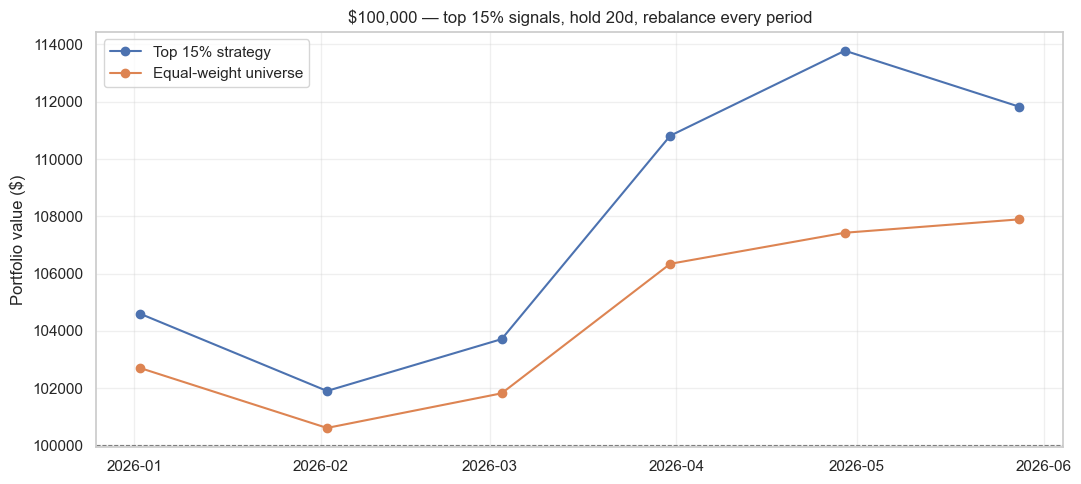

In [92]:
import matplotlib.pyplot as plt

# --- model's P(Outperform) on the test set ---
proba = model_x.predict_proba(X_test)            # (n, 3)
OUTPERFORM = 2

bt = pd.DataFrame({
    "score":   proba[:, OUTPERFORM],
    "fwd_ret": dataset.loc[X_test.index, "fwd_ret"],   # realized skip-5/hold-20 return
}, index=X_test.index).dropna()

# --- assumptions ---
CAPITAL = 100_000
TOP_PCT = 0.15      # top 10% of signals
HOLD    = 20 # 1 trading days
# rebalance every HOLD days -> non-overlapping, contiguous holding windows -> clean compounding
dates = np.sort(bt.index.get_level_values("date").unique())
rebal_dates = dates[::HOLD]

# --- simulate ---
cap_strat, cap_bench = CAPITAL, CAPITAL
rows = []
for d in rebal_dates:
    day = bt.xs(d, level="date")
    n = max(1, int(round(len(day) * TOP_PCT)))
    picks = day.nlargest(n, "score")
    r_strat = picks["fwd_ret"].mean()      # equal-weight top 5%
    r_bench = day["fwd_ret"].mean()        # equal-weight whole universe
    cap_strat *= (1 + r_strat)
    cap_bench *= (1 + r_bench)
    rows.append({"date": d, "n_picks": n, "strat_ret": r_strat,
                 "bench_ret": r_bench, "equity": cap_strat, "bench_equity": cap_bench})

curve = pd.DataFrame(rows).set_index("date")

# --- report ---
ppy = 252 / HOLD
print(f"rebalances: {len(curve)}  |  ~{len(curve)*HOLD} trading days held  |  avg picks/period: {curve['n_picks'].mean():.0f}")
print(f"final value : ${cap_strat:,.0f}   (total {cap_strat/CAPITAL-1:+.1%})")
print(f"benchmark   : ${cap_bench:,.0f}   (total {cap_bench/CAPITAL-1:+.1%})")
print(f"avg period  : strat {curve['strat_ret'].mean():+.2%}  vs  bench {curve['bench_ret'].mean():+.2%}")
print(f"period win rate: {(curve['strat_ret']>0).mean():.0%}   beat-bench rate: {(curve['strat_ret']>curve['bench_ret']).mean():.0%}")
print(f"rough annualized (compounded per-period): {(1+curve['strat_ret'].mean())**ppy-1:+.1%}  [noisy — partial year]")

# --- plot ---
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(curve.index, curve["equity"],       marker="o", label=f"Top {TOP_PCT:.0%} strategy")
ax.plot(curve.index, curve["bench_equity"], marker="o", label="Equal-weight universe")
ax.axhline(CAPITAL, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Portfolio value ($)")
ax.set_title(f"${CAPITAL:,.0f} — top {TOP_PCT:.0%} signals, hold {HOLD}d, rebalance every period")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


--- Rank IC (6 periods) ---
Mean Rank IC : 0.1398
Std Rank IC  : 0.2928
IC IR (mean/std): 0.4774
t-stat       : 1.17
% periods IC > 0: 67%

rebalances: 6 (non-overlapping 20d holds)
strategy (top 5%): $111,908  (+11.9%)
equal-weight univ: $107,893  (+7.9%)
SPY buy & hold   : $110,757  (+10.8%)


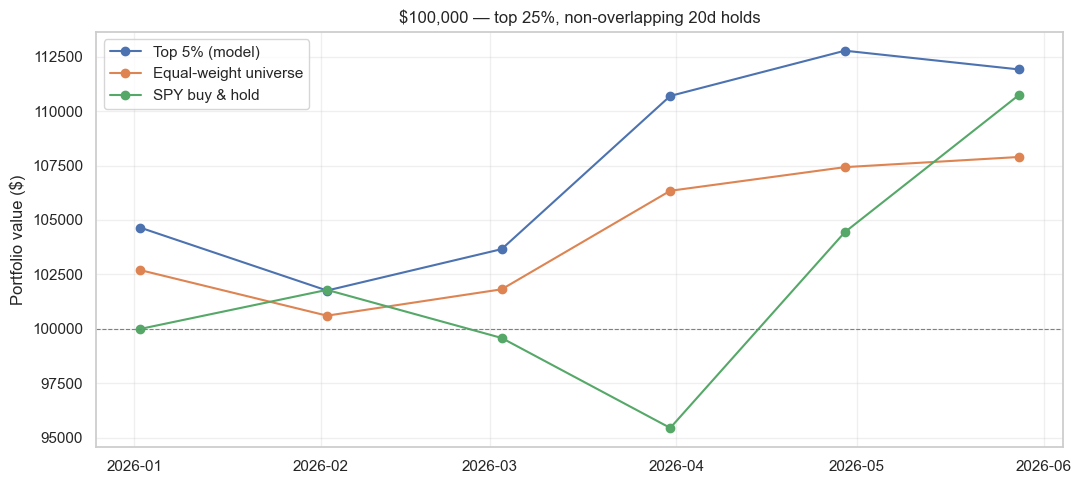

In [134]:
import matplotlib.pyplot as plt

HORIZON, SKIP = 20, 5
CAPITAL, TOP_PCT, HOLD = 100_000, 0.25, HORIZON     # hold == rebalance spacing => no overlap
MIN_PRICE, MAX_MOVE = 5.0, 0.5                        # drop penny funds & bad-tick returns

proba = model_x.predict_proba(X_test)
price_long = prices.stack(); price_long.index.names = ["date", "ticker"]

bt = pd.DataFrame({
    "score":   proba[:, 2],
    "fwd_ret": dataset.loc[X_test.index, "fwd_ret"],
    "price":   price_long.reindex(X_test.index),
}, index=X_test.index).dropna()

# investability guards: real price, sane move (a >50% 20d ETF move is almost always a data error)
bt = bt[(bt["price"] >= MIN_PRICE) & (bt["fwd_ret"].abs() <= MAX_MOVE)]

dates = np.sort(bt.index.get_level_values("date").unique())
rebal_dates = dates[::HOLD]                           # NON-overlapping
rebal_bt = bt[bt.index.get_level_values("date").isin(rebal_dates)]
ic_by_date = (
    rebal_bt
    .groupby(level="date")
    .apply(lambda g: spearmanr(g["score"], g["fwd_ret"])[0] if len(g) > 1 else np.nan)
    .dropna()
)
mean_ic = ic_by_date.mean()
std_ic  = ic_by_date.std()
ic_ir   = mean_ic / std_ic if std_ic > 0 else np.nan
ic_tstat = mean_ic / (std_ic / np.sqrt(len(ic_by_date))) if std_ic > 0 else np.nan
print(f"\n--- Rank IC ({len(ic_by_date)} periods) ---")
print(f"Mean Rank IC : {mean_ic:.4f}")
print(f"Std Rank IC  : {std_ic:.4f}")
print(f"IC IR (mean/std): {ic_ir:.4f}")
print(f"t-stat       : {ic_tstat:.2f}")
print(f"% periods IC > 0: {(ic_by_date > 0).mean():.0%}\n")

spy = prices["SPY"].reindex(rebal_dates).ffill()      # SPY buy-and-hold benchmark

cap_s, cap_u = CAPITAL, CAPITAL
rows = []
for d in rebal_dates:
    day = bt.xs(d, level="date")
    n = max(1, int(round(len(day) * TOP_PCT)))
    r_s = day.nlargest(n, "score")["fwd_ret"].mean()  # top 5% by model
    r_u = day["fwd_ret"].mean()                       # equal-weight universe
    cap_s *= (1 + r_s); cap_u *= (1 + r_u)
    rows.append({"date": d, "strat": cap_s, "universe": cap_u})

curve = pd.DataFrame(rows).set_index("date")
curve["spy"] = CAPITAL * spy / spy.iloc[0]

print(f"rebalances: {len(curve)} (non-overlapping 20d holds)")
print(f"strategy (top 5%): ${curve['strat'].iloc[-1]:,.0f}  ({curve['strat'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"equal-weight univ: ${curve['universe'].iloc[-1]:,.0f}  ({curve['universe'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"SPY buy & hold   : ${curve['spy'].iloc[-1]:,.0f}  ({curve['spy'].iloc[-1]/CAPITAL-1:+.1%})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(curve.index, curve["strat"],    marker="o", label="Top 5% (model)")
ax.plot(curve.index, curve["universe"], marker="o", label="Equal-weight universe")
ax.plot(curve.index, curve["spy"],      marker="o", label="SPY buy & hold")
ax.axhline(CAPITAL, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Portfolio value ($)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f"${CAPITAL:,.0f} — top {TOP_PCT:.0%}, non-overlapping {HOLD}d holds")
plt.tight_layout(); plt.show()

In [133]:
from scipy.stats import spearmanr


# Optuna

CatBoostError: Only one of fname/stream/blob arguments should be specified

In [10]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
model_x= model.load_model(MODEL_DIR / "catboostyuna.cbm", format='cbm')
model_x

CatBoostClassifier(bagging_temperature=1, bootstrap_type='Bayesian', border_count=254, depth=7, eval_metric='TotalF1:average=Macro', iterations=5000, l2_leaf_reg=5, learning_rate=0.045, loss_function='MultiClass', od_wait=200, random_seed=42, random_strength=1, task_type='GPU', use_best_model=True, verbose=100)

In [18]:
print(model.feature_names_)
print("other features")
bang.columns

['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ema20_dist', 'ema50_dist', 'macd', 'macd_signal', 'macd_hist', 'adx_14', 'rsi_14', 'willr_14', 'bb_pctb', 'stoch_k', 'stoch_d', 'vol_20d', 'vol_zscore', 'bb_bandwidth', 'atr_14', 'beta_60d', 'obv', 'mfi_14', 'cmf_20', 'dollar_vol_20d', 'rel_volume_20d', 'cs_rank_ret_5d', 'cs_rank_ret_20d', 'cs_rank_rsi', 'cs_rank_volatility', 'cs_rank_volume', 'peer_rank_20d', 'd_rsi_5d', 'd_peer_rank_5d', 'd_vol_5d', 'd_macd_hist_5d', 'd_volume_pct_5d', 'cat_ret_5d', 'cat_disp_5d', 'beat_rate_20d', 'mkt_ret_1d', 'mkt_vol_20d', 'mkt_vol_zscore', 'breadth_50d']
other features


Index(['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ema20_dist',
       'ema50_dist', 'macd', 'macd_signal', 'macd_hist', 'adx_14', 'rsi_14',
       'willr_14', 'bb_pctb', 'stoch_k', 'stoch_d', 'vol_20d', 'vol_zscore',
       'bb_bandwidth', 'atr_14', 'beta_60d', 'obv', 'mfi_14', 'cmf_20',
       'dollar_vol_20d', 'rel_volume_20d', 'cs_rank_ret_5d', 'cs_rank_ret_20d',
       'cs_rank_rsi', 'cs_rank_volatility', 'cs_rank_volume', 'peer_rank_20d',
       'd_rsi_5d', 'd_peer_rank_5d', 'd_vol_5d', 'd_macd_hist_5d',
       'd_volume_pct_5d', 'cat_ret_5d', 'cat_disp_5d', 'beat_rate_20d',
       'mkt_ret_1d', 'mkt_vol_20d', 'mkt_vol_zscore', 'breadth_50d', 'target',
       'fwd_ret', 'rel'],
      dtype='object')

In [16]:
bang=pd.read_parquet(PROC /"dataset_v3.parquet")
bang


ret_1d    ret_5d   ret_10d   ret_20d   ret_60d  \
date       ticker                                                     
2016-07-11 AADR         NaN       NaN       NaN       NaN       NaN   
           AAXJ         NaN       NaN       NaN       NaN       NaN   
           ACWF         NaN       NaN       NaN       NaN       NaN   
           ACWI         NaN       NaN       NaN       NaN       NaN   
           ACWX         NaN       NaN       NaN       NaN       NaN   
...                     ...       ...       ...       ...       ...   
2026-06-03 YLDE   -0.003158 -0.013116 -0.007815 -0.003591  0.004160   
           YXI     0.019490 -0.007230  0.012442  0.027115  0.023014   
           YYY    -0.013055 -0.013055  0.006892 -0.007068  0.048193   
           ZIG    -0.000051 -0.008809  0.022525 -0.000152  0.020148   
           ZROZ   -0.004758  0.009817  0.055509  0.005770 -0.053399   

                   ema20_dist  ema50_dist      macd  macd_signal  macd_hist  \
date       ticker                                                             
2016-07-11 AADR      0.000000    0.000000  0.000000     0.000000   0.000000   
           AAXJ      0.000000    0.000000  0.000000     0.000000   0.000000   
           ACWF      0.000000    0.000000  0.000000     0.000000   0.000000   
           ACWI      0.000000    0.000000  0.000000     0.000000   0.000000   
           ACWX      0.000000    0.000000  0.000000     0.000000   0.000000   
...                       ...         ...       ...          ...        ...   
2026-06-03 YLDE     -0.004854    0.000501  0.093332     0.172424  -0.079093   
           YXI       0.011902    0.024326  0.200041     0.168006   0.032035   
           YYY      -0.006889    0.003131  0.050418     0.062143  -0.011725   
           ZIG       0.003451    0.006972  0.084387     0.033178   0.051209   
           ZROZ      0.010213    0.002161  0.010490    -0.272021   0.282511   

                   ...  cat_ret_5d  cat_disp_5d  beat_rate_20d  mkt_ret_1d  \
date       ticker  ...                                                       
2016-07-11 AADR    ...         NaN          NaN       0.000000         NaN   
           AAXJ    ...         NaN          NaN       0.000000         NaN   
           ACWF    ...         NaN          NaN       0.000000         NaN   
           ACWI    ...         NaN          NaN       0.000000         NaN   
           ACWX    ...         NaN          NaN       0.000000         NaN   
...                ...         ...          ...            ...         ...   
2026-06-03 YLDE    ...    0.000603     0.012661       0.483333    -0.00525   
           YXI     ...    0.001833     0.020202       0.361963    -0.00525   
           YYY     ...    0.004372     0.014341       0.389610    -0.00525   
           ZIG     ...    0.005486     0.015432       0.482014    -0.00525   
           ZROZ    ...    0.000850     0.002741       0.500000    -0.00525   

                   mkt_vol_20d  mkt_vol_zscore  breadth_50d  target   fwd_ret  \
date       ticker                                                               
2016-07-11 AADR            NaN             NaN     0.000000       0  0.011084   
           AAXJ            NaN             NaN     0.000000       2  0.051138   
           ACWF            NaN             NaN     0.000000       2  0.023605   
           ACWI            NaN             NaN     0.000000       2  0.025566   
           ACWX            NaN             NaN     0.000000       2  0.036124   
...                        ...             ...          ...     ...       ...   
2026-06-03 YLDE       0.005173         0.24195     0.786254       1  0.035725   
           YXI        0.005173         0.24195     0.786254       0  0.023948   
           YYY        0.005173         0.24195     0.786254       2  0.041139   
           ZIG        0.005173         0.24195     0.786254       0 -0.006989   
           ZROZ       0.005173         0.24195     0.786254       0 -0.004285   



In [20]:
yum=bang.drop(columns=['target',"fwd_ret","rel"])

In [35]:
feature_importance = pd.DataFrame({
    "feature": yum.columns,
    "importance": model_x.get_feature_importance()
}).sort_values("importance", ascending=False)
feature_importance

,feature,importance
20,beta_60d,17.104561
42,mkt_vol_zscore,14.056456
41,mkt_vol_20d,11.661731
16,vol_20d,8.740340
43,breadth_50d,8.455662
29,cs_rank_volatility,8.406677
4,ret_60d,5.180624
31,peer_rank_20d,4.622112
17,vol_zscore,3.919240
38,cat_disp_5d,3.006437


In [19]:
WINDOW_MONTHS = 48

train_start = test_start - pd.DateOffset(months=WINDOW_MONTHS)

train_mask = (date_index >= train_start) & (date_index <= cut)

train = dataset.loc[train_mask]

train_dates = train.index.get_level_values("date")
dates = np.sort(train_dates.unique())

val_start = dates[int(len(dates) * 0.90)]
val_cut = val_start - pd.offsets.BDay(EMBARGO)

fit_mask = train_dates <= val_cut
val_mask = train_dates >= val_start

X_fit = train.loc[fit_mask, features]
y_fit = train.loc[fit_mask, target]

X_val = train.loc[val_mask, features]
y_val = train.loc[val_mask, target]

print(len(X_fit), len(X_val))

1217883 129611


In [22]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=100
)

[I 2026-07-15 13:32:47,998] A new study created in memory with name: no-name-7bcd8035-ce24-4176-a9ae-de1297b989b1
[I 2026-07-15 13:32:53,689] Trial 0 finished with value: 0.4534126706538069 and parameters: {'iterations': 421, 'learning_rate': 0.010491154419155697, 'depth': 7, 'l2_leaf_reg': 3.982608724085118, 'random_strength': 0.872088286086905, 'bagging_temperature': 2.332699593172051, 'border_count': 254}. Best is trial 0 with value: 0.4534126706538069.
[I 2026-07-15 13:32:59,308] Trial 1 finished with value: 0.4494961762513881 and parameters: {'iterations': 1338, 'learning_rate': 0.06543142109780119, 'depth': 8, 'l2_leaf_reg': 1.8589866313480374, 'random_strength': 2.699593597979348, 'bagging_temperature': 3.247426089353493, 'border_count': 128}. Best is trial 0 with value: 0.4534126706538069.
[I 2026-07-15 13:33:05,019] Trial 2 finished with value: 0.452086880325764 and parameters: {'iterations': 2822, 'learning_rate': 0.03737303051600977, 'depth': 8, 'l2_leaf_reg': 8.295009503023

# Model

top 25% | hold 5d | rebalances: 25 | avg picks/period: 331
strategy : $110,440  (+10.4%)
universe : $109,807  (+9.8%)
SPY B&H  : $107,274  (+7.3%)
avg period: strat +0.411% vs univ +0.382%
period win rate: 56%  beat-univ rate: 52%
rough annualized: +22.9%  [noisy]


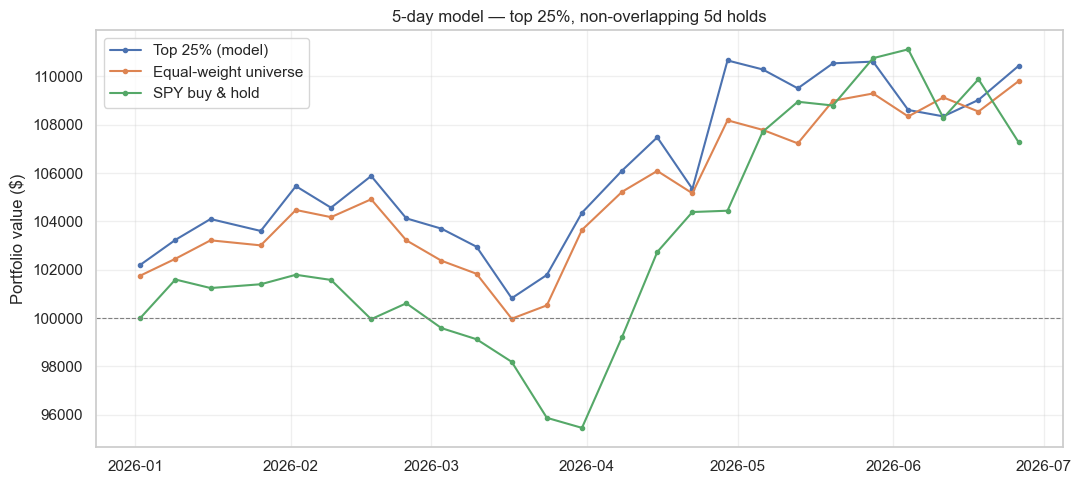

In [128]:
import matplotlib.pyplot as plt

# ---- knobs to play with ----
TOP_PCT = 0.25          # fraction of universe held (small = confident picks; 0.6 = basically everything)
HOLD    = 5             # holding period = rebalance spacing (non-overlapping)
CAPITAL = 100_000
MIN_PRICE, MAX_MOVE = 5.0, 0.25

# ---- leakage-free holdout predictions ----
bt = pd.read_parquet(PROC / "backtest_5d.parquet").dropna()
bt = bt[(bt["price"] >= MIN_PRICE) & (bt["fwd_ret"].abs() <= MAX_MOVE)]
prices = pd.read_parquet(RAW / "prices.parquet")

dates = np.sort(bt.index.get_level_values("date").unique())
rebal_dates = dates[::HOLD]
spy = prices["SPY"].reindex(rebal_dates).ffill()

# ---- simulate ----
cap_s = cap_u = CAPITAL
rows = []
for d in rebal_dates:
    day = bt.xs(d, level="date")
    n = max(1, int(round(len(day) * TOP_PCT)))
    r_s = day.nlargest(n, "score")["fwd_ret"].mean()   # top TOP_PCT by model score
    r_u = day["fwd_ret"].mean()                        # equal-weight universe
    cap_s *= (1 + r_s); cap_u *= (1 + r_u)
    rows.append({"date": d, "n_picks": n,
                 "strat_ret": r_s, "univ_ret": r_u,
                 "strat_eq": cap_s, "univ_eq": cap_u})

curve = pd.DataFrame(rows).set_index("date")
curve["spy_eq"] = CAPITAL * spy.values / spy.values[0]

# ---- report ----
ppy = 252 / HOLD
print(f"top {TOP_PCT:.0%} | hold {HOLD}d | rebalances: {len(curve)} | avg picks/period: {curve['n_picks'].mean():.0f}")
print(f"strategy : ${curve['strat_eq'].iloc[-1]:,.0f}  ({curve['strat_eq'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"universe : ${curve['univ_eq'].iloc[-1]:,.0f}  ({curve['univ_eq'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"SPY B&H  : ${curve['spy_eq'].iloc[-1]:,.0f}  ({curve['spy_eq'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"avg period: strat {curve['strat_ret'].mean():+.3%} vs univ {curve['univ_ret'].mean():+.3%}")
print(f"period win rate: {(curve['strat_ret']>0).mean():.0%}  beat-univ rate: {(curve['strat_ret']>curve['univ_ret']).mean():.0%}")
print(f"rough annualized: {(1+curve['strat_ret'].mean())**ppy-1:+.1%}  [noisy]")

# ---- plot ----
fig, ax = plt.subplots(figsize=(11, 5))
for col, lab in [("strat_eq", f"Top {TOP_PCT:.0%} (model)"),
                 ("univ_eq", "Equal-weight universe"),
                 ("spy_eq", "SPY buy & hold")]:
    ax.plot(curve.index, curve[col], marker="o", ms=3, label=lab)
ax.axhline(CAPITAL, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Portfolio value ($)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f"5-day model — top {TOP_PCT:.0%}, non-overlapping {HOLD}d holds")
plt.tight_layout(); plt.show()

mean rank IC : +0.0723
IC std       : 0.2314
IC info-ratio: +0.313
IC t-stat    : +3.49   (significant)
positive days: 59%


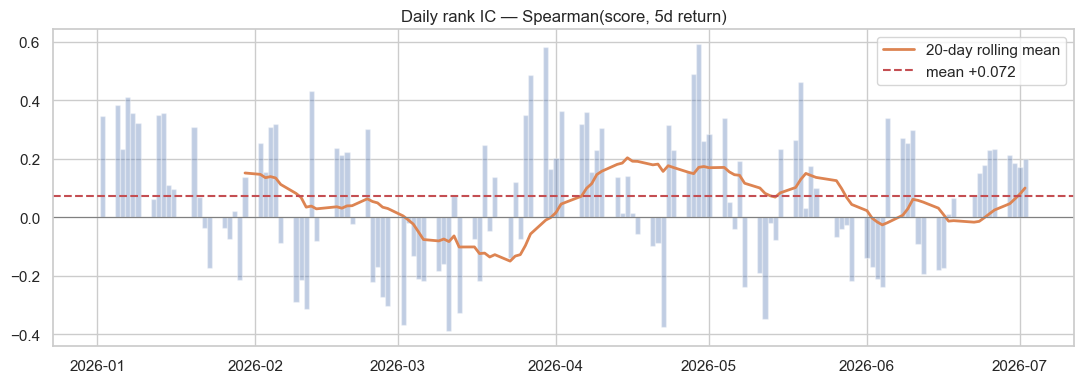

In [135]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet(PROC / "backtest_5d.parquet").dropna()   # has score + fwd_ret, indexed (date, ticker)

# step 1+2: daily Spearman(score, realized return) across funds
daily_ic = df.groupby(level="date").apply(
    lambda d: d["score"].corr(d["fwd_ret"], method="spearman"))

# step 3: summarize
mean_ic = daily_ic.mean()
ic_ir   = mean_ic / daily_ic.std()             # "IC information ratio" — consistency
t_stat  = ic_ir * np.sqrt(len(daily_ic))       # is it distinguishable from 0?
hit     = (daily_ic > 0).mean()                # fraction of days with positive IC

print(f"mean rank IC : {mean_ic:+.4f}")
print(f"IC std       : {daily_ic.std():.4f}")
print(f"IC info-ratio: {ic_ir:+.3f}")
print(f"IC t-stat    : {t_stat:+.2f}   ({'significant' if abs(t_stat) > 2 else 'NOT significant'})")
print(f"positive days: {hit:.0%}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(daily_ic.index, daily_ic.values, width=1, alpha=0.35)
ax.plot(daily_ic.index, daily_ic.rolling(20).mean(), color="C1", lw=2, label="20-day rolling mean")
ax.axhline(0, color="gray", lw=0.8)
ax.axhline(mean_ic, color="C3", ls="--", label=f"mean {mean_ic:+.3f}")
ax.set_title("Daily rank IC — Spearman(score, 5d return)"); ax.legend()
plt.tight_layout(); plt.show()

periods      : 6
mean rank IC : +0.1398
IC std       : 0.2928
IC info-ratio: +0.477
IC t-stat    : +1.17   (NOT significant)
positive periods: 67%


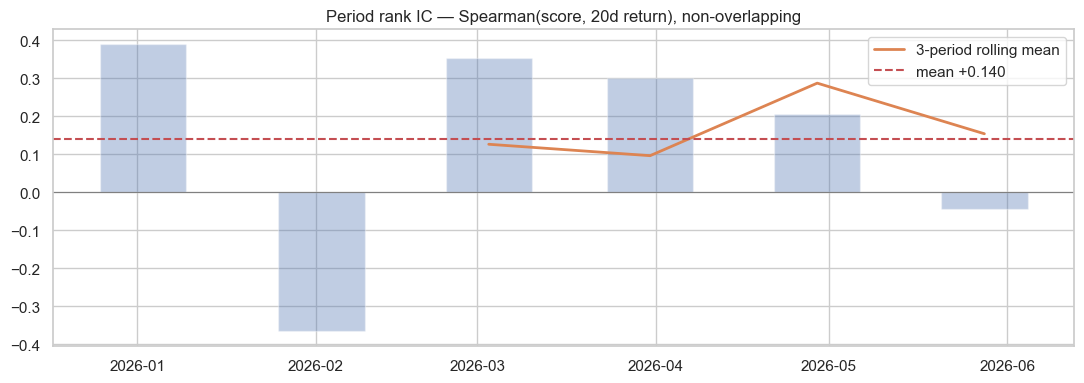

In [136]:
# --- daily/period rank IC for the top-25% / 20d backtest ---

# use the same filtered bt and rebalance dates as the portfolio sim
ic_bt = bt[bt.index.get_level_values("date").isin(rebal_dates)]

# step 1+2: per-period Spearman(score, realized return) across funds
period_ic = ic_bt.groupby(level="date").apply(
    lambda d: d["score"].corr(d["fwd_ret"], method="spearman"))

# step 3: summarize
mean_ic = period_ic.mean()
ic_ir   = mean_ic / period_ic.std()             # "IC information ratio" — consistency
t_stat  = ic_ir * np.sqrt(len(period_ic))       # is it distinguishable from 0?
hit     = (period_ic > 0).mean()                # fraction of periods with positive IC

print(f"periods      : {len(period_ic)}")
print(f"mean rank IC : {mean_ic:+.4f}")
print(f"IC std       : {period_ic.std():.4f}")
print(f"IC info-ratio: {ic_ir:+.3f}")
print(f"IC t-stat    : {t_stat:+.2f}   ({'significant' if abs(t_stat) > 2 else 'NOT significant'})")
print(f"positive periods: {hit:.0%}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(period_ic.index, period_ic.values, width=15, alpha=0.35)
ax.plot(period_ic.index, period_ic.rolling(3).mean(), color="C1", lw=2, label="3-period rolling mean")
ax.axhline(0, color="gray", lw=0.8)
ax.axhline(mean_ic, color="C3", ls="--", label=f"mean {mean_ic:+.3f}")
ax.set_title(f"Period rank IC — Spearman(score, {HORIZON}d return), non-overlapping")
ax.legend()
plt.tight_layout(); plt.show()

In [138]:
import numpy as np, pandas as pd

# 20d model, predictions over ALL test dates (use the full X_test, not the rebalance frame)
proba = model_x.predict_proba(X_test)
ic_df = pd.DataFrame({
    "score":   proba[:, 2],
    "fwd_ret": dataset.loc[X_test.index, "fwd_ret"],
}, index=X_test.index).dropna()

# daily rank IC across EVERY date
daily_ic = ic_df.groupby(level="date").apply(
    lambda d: d["score"].corr(d["fwd_ret"], method="spearman")).dropna()

mean_ic = daily_ic.mean()
ic_ir   = mean_ic / daily_ic.std()
t_stat  = ic_ir * np.sqrt(len(daily_ic))
print(f"dates        : {len(daily_ic)}")
print(f"mean rank IC : {mean_ic:+.4f}")
print(f"IC std       : {daily_ic.std():.4f}")
print(f"IC info-ratio: {ic_ir:+.3f}")
print(f"IC t-stat    : {t_stat:+.2f}   ({'significant' if abs(t_stat) > 2 else 'NOT significant'})")
print(f"positive days: {(daily_ic > 0).mean():.0%}")

dates        : 105
mean rank IC : +0.1319
IC std       : 0.2762
IC info-ratio: +0.477
IC t-stat    : +4.89   (significant)
positive days: 66%


LONG-ONLY top 20%  |  25 periods, 5d holds
long-only : $108,833  (+8.8%)
universe  : $109,807  (+9.8%)
SPY B&H   : $107,274  (+7.3%)
Sharpe    : +1.51   win: 56%   beat-univ: 48%


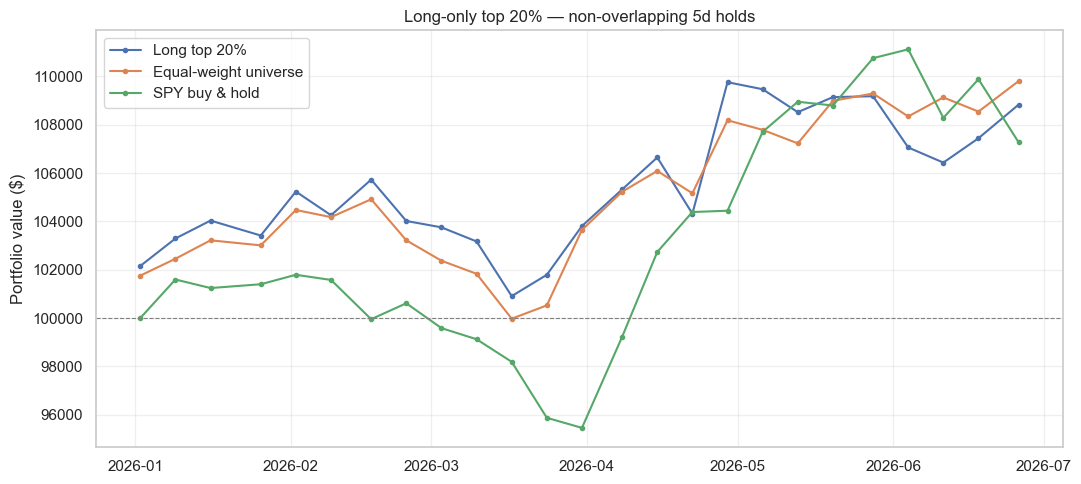

In [145]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- knobs ---
BT_PATH = PROC / "backtest_5d.parquet"    # or "backtest_20d_v3.parquet"
HOLD    = 5                                # 5 for the 5d model, 20 for the 20d
TOP_PCT = 0.20                             # long the top 20% by score
CAPITAL = 100_000
MIN_PRICE, MAX_MOVE = 5.0, 0.25           # use MAX_MOVE=0.5 for the 20d model

bt = pd.read_parquet(BT_PATH).dropna()
if "price" not in bt.columns:              # 20d frame doesn't carry price; pull it in
    pl = prices.stack(); pl.index.names = ["date", "ticker"]
    bt["price"] = pl.reindex(bt.index)
bt = bt.dropna(subset=["price"])
bt = bt[(bt["price"] >= MIN_PRICE) & (bt["fwd_ret"].abs() <= MAX_MOVE)]

dates = np.sort(bt.index.get_level_values("date").unique())
rebal = dates[::HOLD]
spy = prices["SPY"].reindex(rebal).ffill()

cap_l = cap_u = CAPITAL
rows = []
for d in rebal:
    day = bt.xs(d, level="date")
    n = max(1, int(round(len(day) * TOP_PCT)))
    r_l = day.nlargest(n, "score")["fwd_ret"].mean()   # LONG top quintile only
    r_u = day["fwd_ret"].mean()                        # equal-weight universe
    cap_l *= (1 + r_l); cap_u *= (1 + r_u)
    rows.append({"date": d, "long": r_l, "univ": r_u, "long_eq": cap_l, "univ_eq": cap_u})

curve = pd.DataFrame(rows).set_index("date")
curve["spy_eq"] = CAPITAL * spy.values / spy.values[0]

ppy = 252 / HOLD
print(f"LONG-ONLY top {TOP_PCT:.0%}  |  {len(curve)} periods, {HOLD}d holds")
print(f"long-only : ${curve['long_eq'].iloc[-1]:,.0f}  ({curve['long_eq'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"universe  : ${curve['univ_eq'].iloc[-1]:,.0f}  ({curve['univ_eq'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"SPY B&H   : ${curve['spy_eq'].iloc[-1]:,.0f}  ({curve['spy_eq'].iloc[-1]/CAPITAL-1:+.1%})")
print(f"Sharpe    : {curve['long'].mean()/curve['long'].std()*np.sqrt(ppy):+.2f}   "
      f"win: {(curve['long']>0).mean():.0%}   beat-univ: {(curve['long']>curve['univ']).mean():.0%}")

fig, ax = plt.subplots(figsize=(11, 5))
for col, lab in [("long_eq", f"Long top {TOP_PCT:.0%}"), ("univ_eq", "Equal-weight universe"), ("spy_eq", "SPY buy & hold")]:
    ax.plot(curve.index, curve[col], marker="o", ms=3, label=lab)
ax.axhline(CAPITAL, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Portfolio value ($)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f"Long-only top {TOP_PCT:.0%} — non-overlapping {HOLD}d holds")
plt.tight_layout(); plt.show()

In [1]:
model_x


NameError: name 'model_x' is not defined